In [29]:
import os
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

In [2]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [3]:
# Custom loader function for .npy files
def npy_loader(path):
    """Load .npy file and convert to tensor"""
    image = np.load(path).astype(np.float32)
    
    image = torch.from_numpy(image)

    # Add channel dimension
    if image.ndim == 2:
        image = image.unsqueeze(0)  # (H, W) -> (1, H, W)
    
    # Convert single channel to 3-channel for ResNet (expects RGB)
    if image.shape[0] == 1:
        image = image.repeat(3, 1, 1)  # (1, H, W) -> (3, H, W)
    
    return image

synth_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "alvin_edited_files/log_mapping/synth"),
    extensions = (".npy"),
    loader = npy_loader
)
meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "alvin_edited_files/log_mapping/real"),
    extensions = (".npy"),
    loader = npy_loader
)

In [4]:
def extract_elev(path):
    match = re.search(r"elevDeg_(\d{3})", path)
    if match:
        return int(match.group(1))
    return None

def filter_by_elev(dataset, allowed_angles):
    filtered = []
    ds_cp = copy.deepcopy(dataset)
    for path, label in dataset.samples:
        elev = extract_elev(path)
        if elev in allowed_angles:
            filtered.append((path, label))
    ds_cp.samples = filtered
    ds_cp.targets = [label for _, label in filtered]
    return ds_cp

In [5]:
train_ds = filter_by_elev(synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

## Batch 32

In [6]:
ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

# dataloaders = {x : DataLoader(ds_dict[x], batch_size = 32, num_workers = 5, shuffle = True) for x in ds_dict.keys()}
dataloaders = {
    "train": DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=5),
    "val": DataLoader(valid_ds, batch_size=32, shuffle=False, num_workers=5),
    "test": DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=5)
}

In [50]:
train_loss = []
val_loss = []
train_acc =[]
val_acc = []

for i in range(10):
    print(f"Training Run {i}")
    # load pre-trained model
    model = models.resnet18(weights = "DEFAULT")

    # Replace final layer for the number of classes
    model.fc = nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    
    optimizer = optim.Adam(model.parameters(), lr = 3e-5)
    
    # scheduler = CosineAnnealingLR(optimizer, T_max = 100)
    scheduler = OneCycleLR(
        optimizer, 
        max_lr = 1.25e-4, 
        steps_per_epoch = len(dataloaders["train"]), 
        epochs = 100
        )
        
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    history = {
        "train_loss": [],
        "val_loss" : [],
        "train_acc": [],
        "val_acc" : []
    }
    
    # Training loops
    num_epochs = 100
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
    
            running_loss = 0.0
            running_corrects = 0 # correct predictions
    
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad() # clear the gradient from previous iteration
    
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels) # check if output and labels match
    
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                        scheduler.step() # scheduler here if OneCycleLR
    
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
    
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
    
            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    
        # scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")

        if epoch == 0:
            torch.save(copy.deepcopy(model.state_dict()), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32_epoch0.pth"))
        
    print("Training complete!")
    
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
    
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32.pth"))

train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0
Epoch 0
train Loss: 2.3854 Acc: 0.1203
val Loss: 2.5146 Acc: 0.0620
Epoch 0 LR: 0.0000053295
Epoch 1
train Loss: 2.0760 Acc: 0.2481
val Loss: 2.5837 Acc: 0.0831
Epoch 1 LR: 0.0000063145
Epoch 2
train Loss: 1.8703 Acc: 0.3325
val Loss: 2.4997 Acc: 0.0856
Epoch 2 LR: 0.0000079441
Epoch 3
train Loss: 1.6232 Acc: 0.4963
val Loss: 2.4489 Acc: 0.1104
Epoch 3 LR: 0.0000102004
Epoch 4
train Loss: 1.3972 Acc: 0.6600
val Loss: 2.4376 Acc: 0.1315
Epoch 4 LR: 0.0000130587
Epoch 5
train Loss: 1.1516 Acc: 0.8015
val Loss: 2.4212 Acc: 0.1439
Epoch 5 LR: 0.0000164874
Epoch 6
train Loss: 0.8910 Acc: 0.8859
val Loss: 2.4548 Acc: 0.1588
Epoch 6 LR: 0.0000204491
Epoch 7
train Loss: 0.6341 Acc: 0.9442
val Loss: 2.5084 Acc: 0.1849
Epoch 7 LR: 0.0000249001
Epoch 8
train Loss: 0.4311 Acc: 0.9690
val Loss: 2.5306 Acc: 0.2010
Epoch 8 LR: 0.0000297916
Epoch 9
train Loss: 0.2823 Acc: 0.9901
val Loss: 2.5980 Acc: 0.1973
Epoch 9 LR: 0.0000350699
Epoch 10
train Loss: 0.1674 Acc: 1.0000
val Loss: 2.680

IOStream.flush timed out


train Loss: 0.0011 Acc: 1.0000
val Loss: 1.8430 Acc: 0.4640
Epoch 63 LR: 0.0000651965
Epoch 64
train Loss: 0.0007 Acc: 1.0000
val Loss: 1.8850 Acc: 0.4603
Epoch 64 LR: 0.0000623924
Epoch 65
train Loss: 0.0008 Acc: 1.0000
val Loss: 1.7637 Acc: 0.4777
Epoch 65 LR: 0.0000595884
Epoch 66
train Loss: 0.0012 Acc: 1.0000
val Loss: 1.8286 Acc: 0.4702
Epoch 66 LR: 0.0000567904
Epoch 67
train Loss: 0.0009 Acc: 1.0000
val Loss: 1.7044 Acc: 0.4926
Epoch 67 LR: 0.0000540038
Epoch 68
train Loss: 0.0005 Acc: 1.0000
val Loss: 1.8152 Acc: 0.4839
Epoch 68 LR: 0.0000512344
Epoch 69
train Loss: 0.0054 Acc: 0.9988
val Loss: 1.7920 Acc: 0.4789
Epoch 69 LR: 0.0000484876
Epoch 70
train Loss: 0.0123 Acc: 0.9963
val Loss: 1.8391 Acc: 0.4665
Epoch 70 LR: 0.0000457690
Epoch 71
train Loss: 0.0157 Acc: 0.9938
val Loss: 2.0546 Acc: 0.4194
Epoch 71 LR: 0.0000430842
Epoch 72
train Loss: 0.0211 Acc: 0.9950
val Loss: 1.7779 Acc: 0.5050
Epoch 72 LR: 0.0000404384
Epoch 73
train Loss: 0.0093 Acc: 0.9963
val Loss: 1.7412 Ac

IOStream.flush timed out


train Loss: 0.0019 Acc: 1.0000
val Loss: 2.3956 Acc: 0.3610
Epoch 43 LR: 0.0001130001
Epoch 44
train Loss: 0.0014 Acc: 1.0000
val Loss: 2.3817 Acc: 0.3623
Epoch 44 LR: 0.0001112972
Epoch 45
train Loss: 0.0074 Acc: 0.9975
val Loss: 2.2890 Acc: 0.3797
Epoch 45 LR: 0.0001094960
Epoch 46
train Loss: 0.0186 Acc: 0.9950
val Loss: 2.6505 Acc: 0.3002
Epoch 46 LR: 0.0001076001
Epoch 47
train Loss: 0.0195 Acc: 0.9963
val Loss: 2.4661 Acc: 0.3449
Epoch 47 LR: 0.0001056135
Epoch 48
train Loss: 0.0066 Acc: 0.9988
val Loss: 2.1165 Acc: 0.3834
Epoch 48 LR: 0.0001035400
Epoch 49
train Loss: 0.0050 Acc: 0.9988
val Loss: 2.0459 Acc: 0.3958
Epoch 49 LR: 0.0001013838
Epoch 50
train Loss: 0.0031 Acc: 1.0000
val Loss: 1.9327 Acc: 0.4156
Epoch 50 LR: 0.0000991493
Epoch 51
train Loss: 0.0027 Acc: 1.0000
val Loss: 2.0302 Acc: 0.3945
Epoch 51 LR: 0.0000968411
Epoch 52
train Loss: 0.0118 Acc: 0.9963
val Loss: 2.1861 Acc: 0.3772
Epoch 52 LR: 0.0000944637
Epoch 53
train Loss: 0.0039 Acc: 1.0000
val Loss: 1.9750 Ac

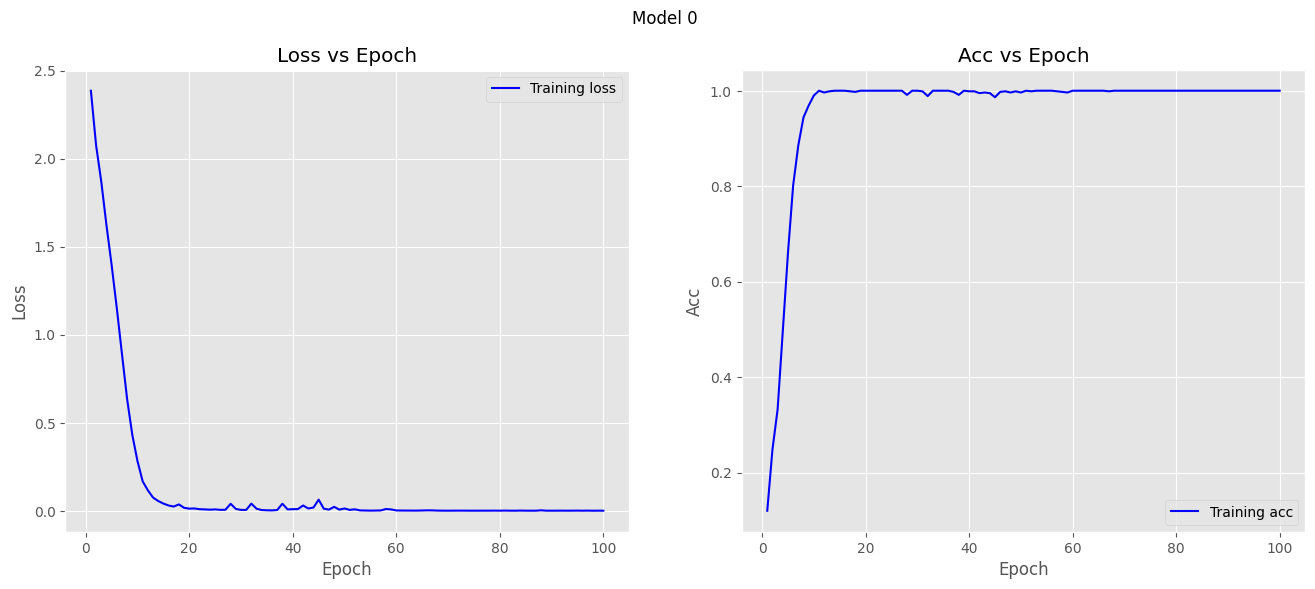

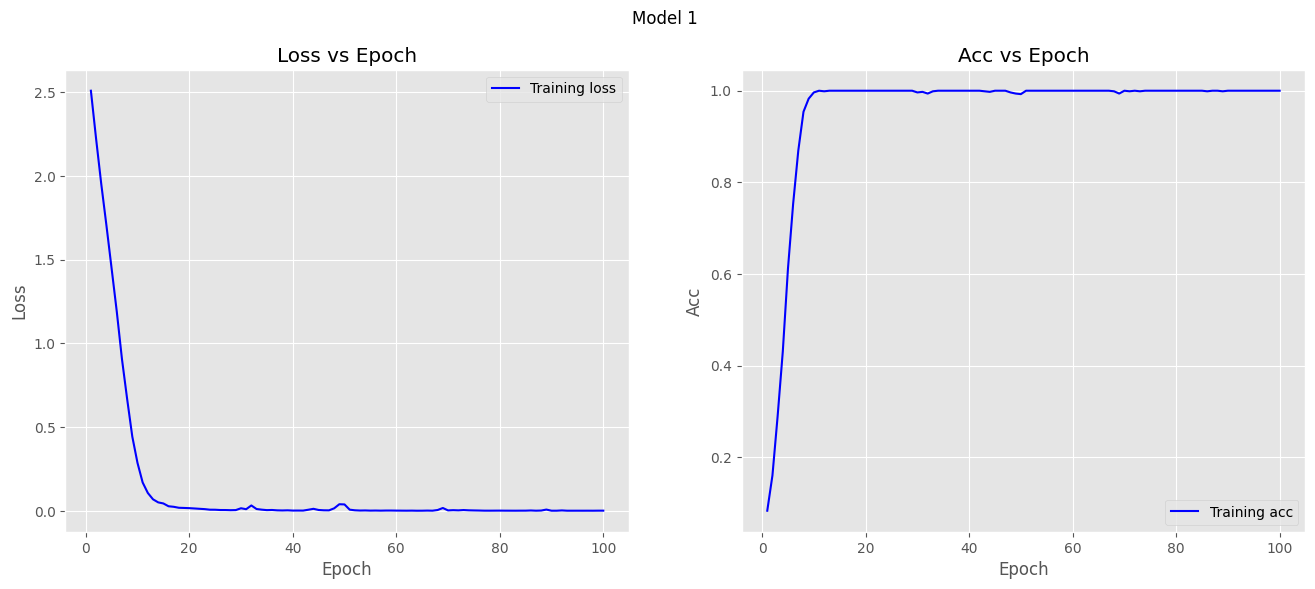

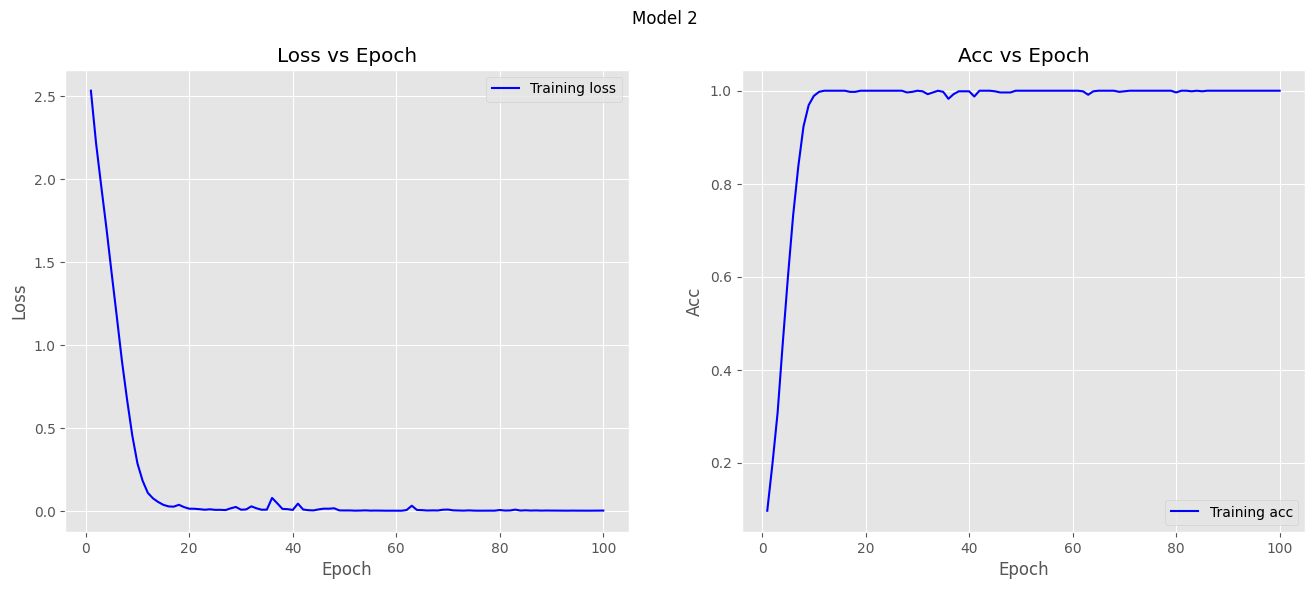

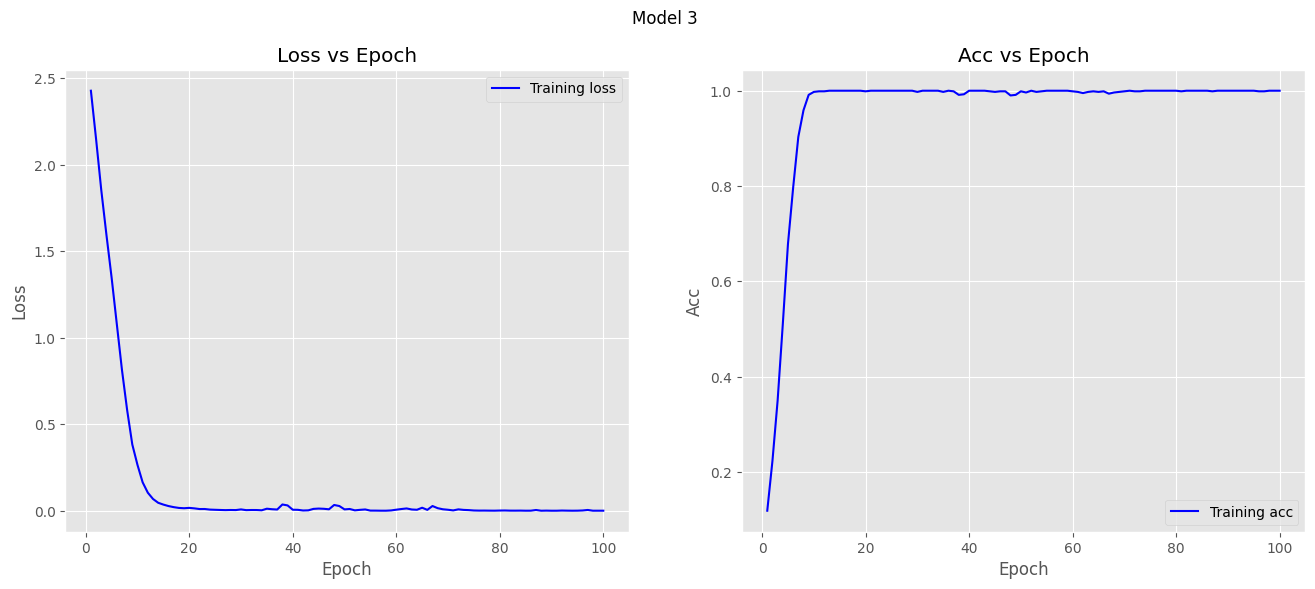

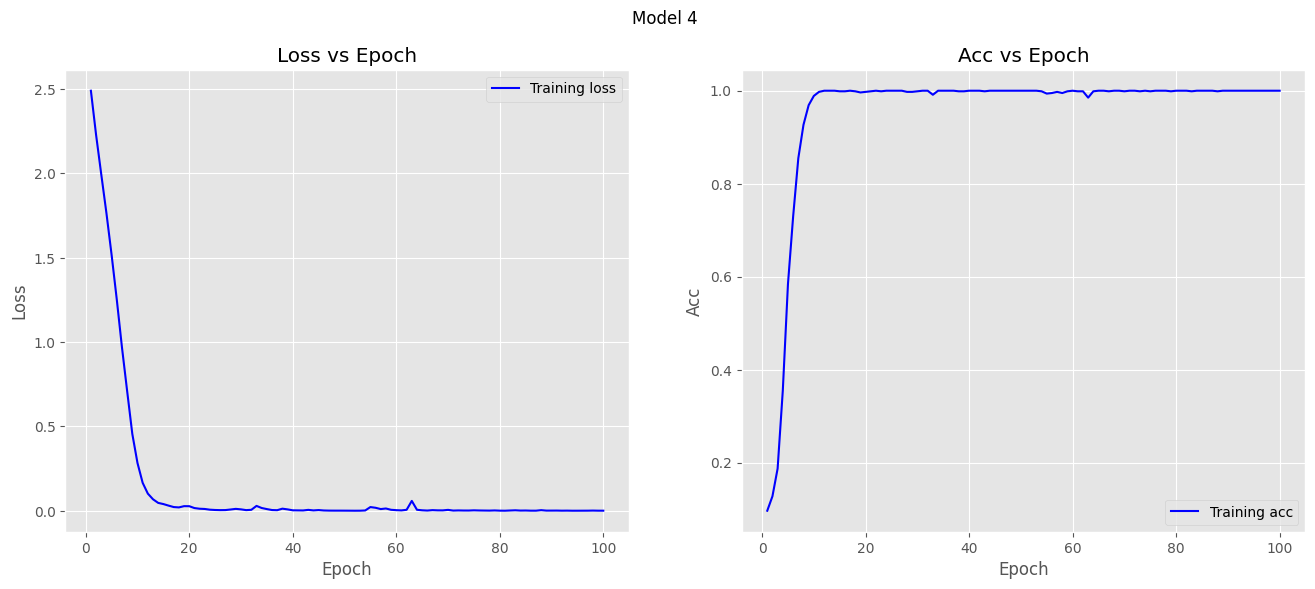

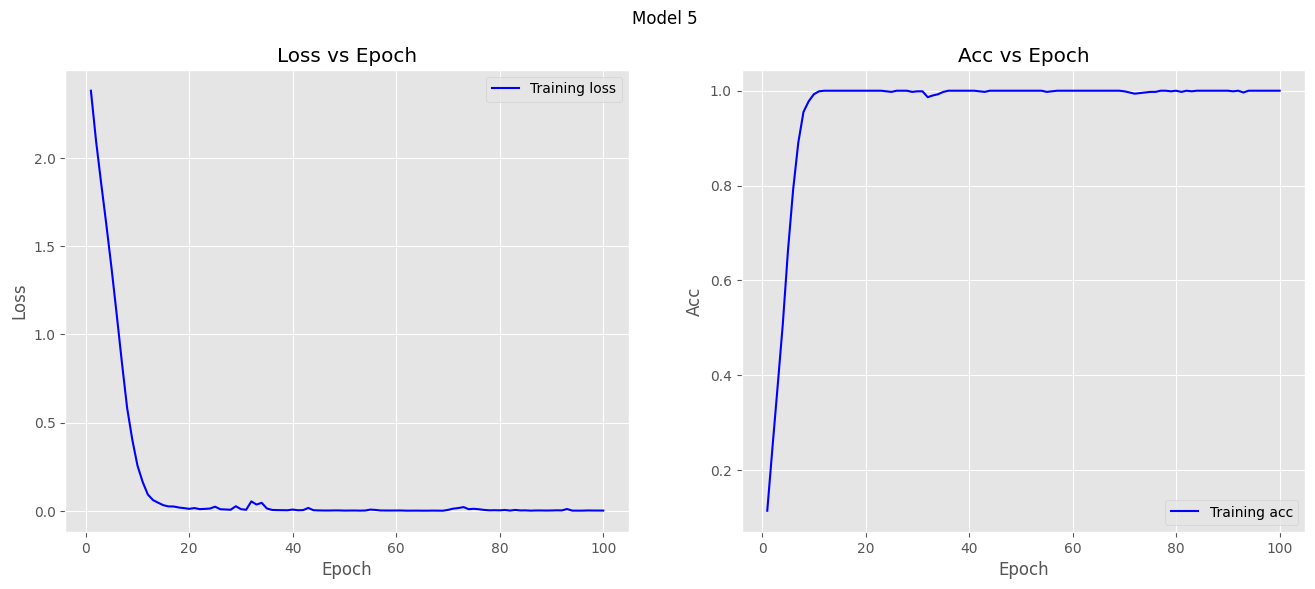

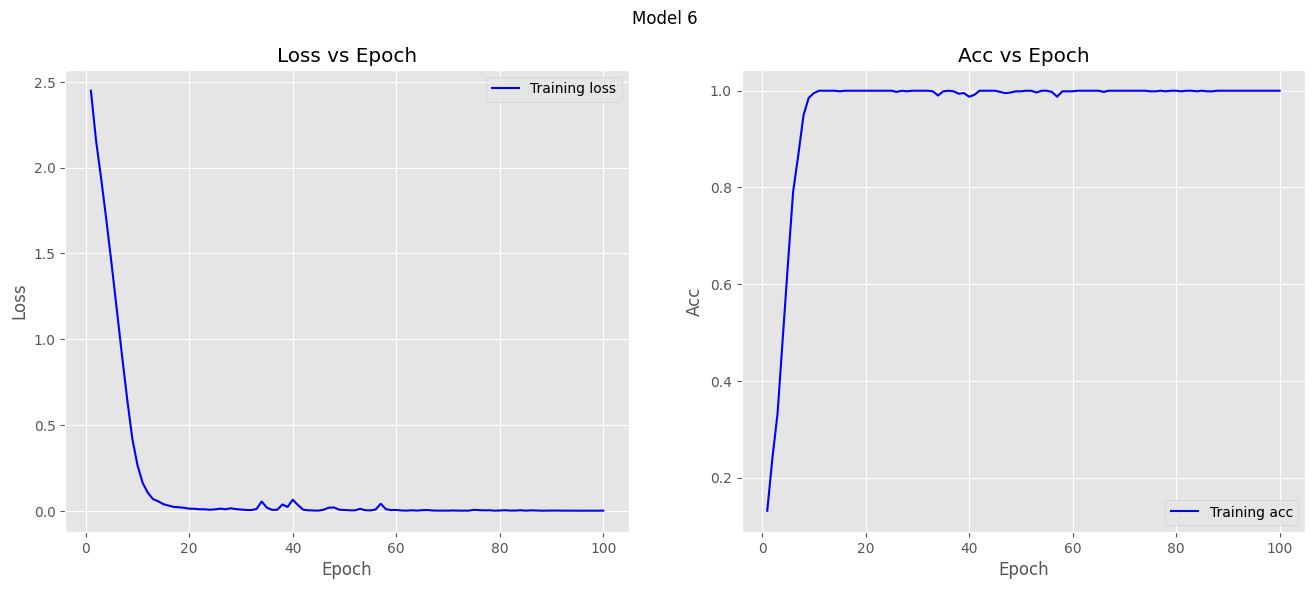

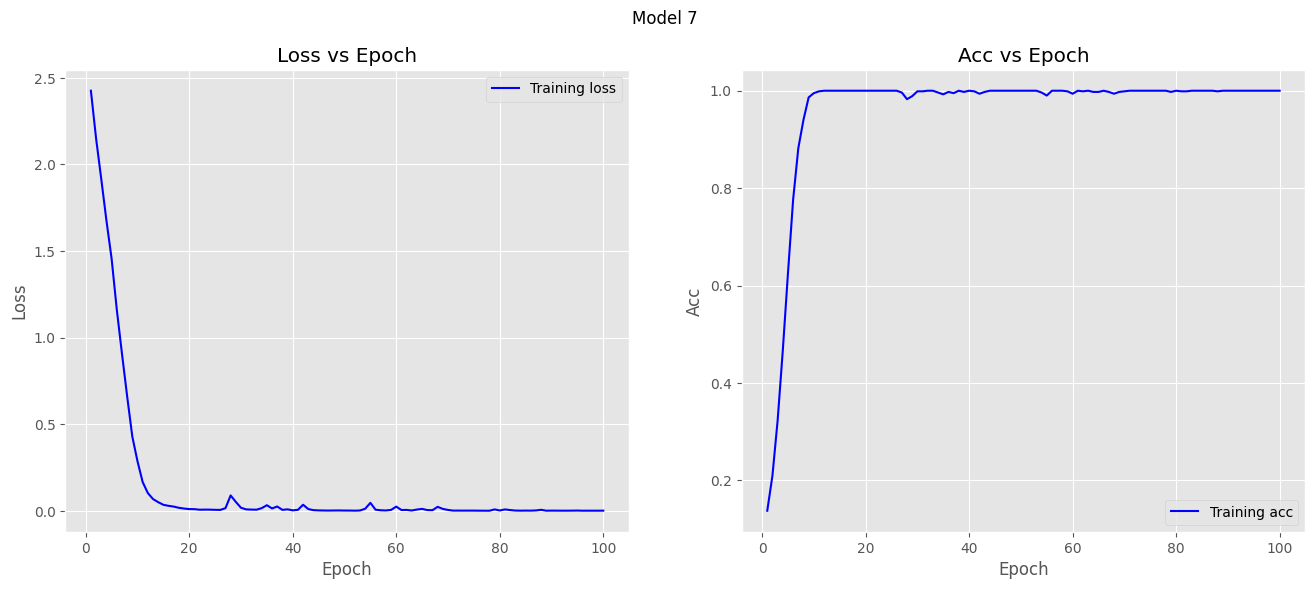

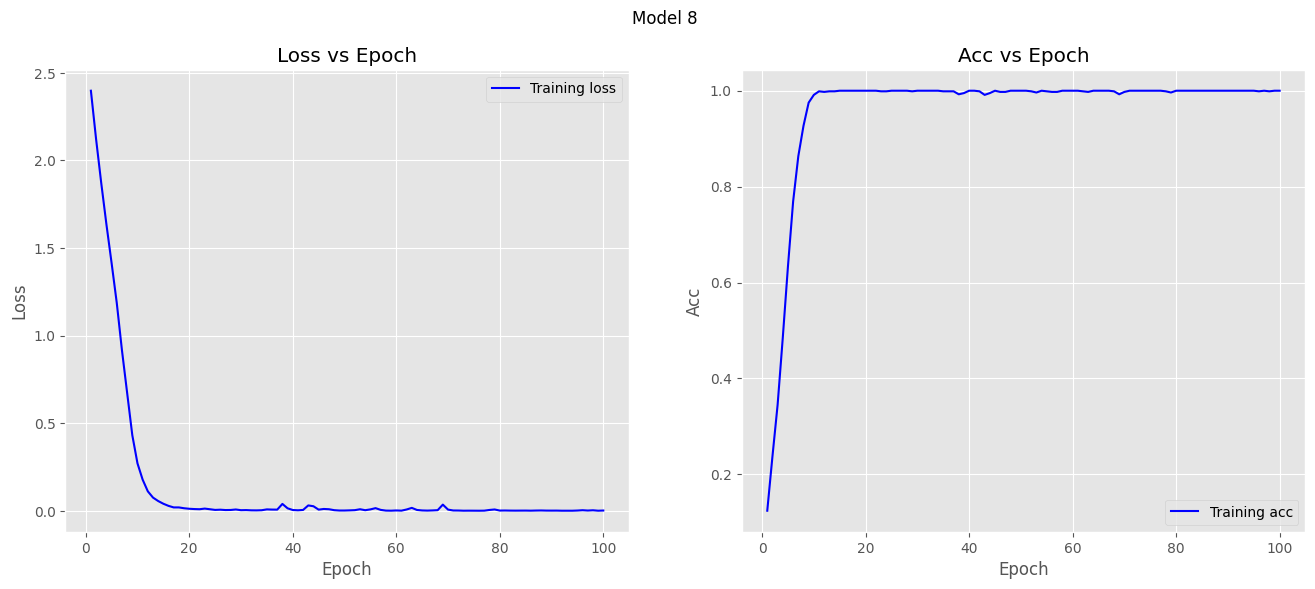

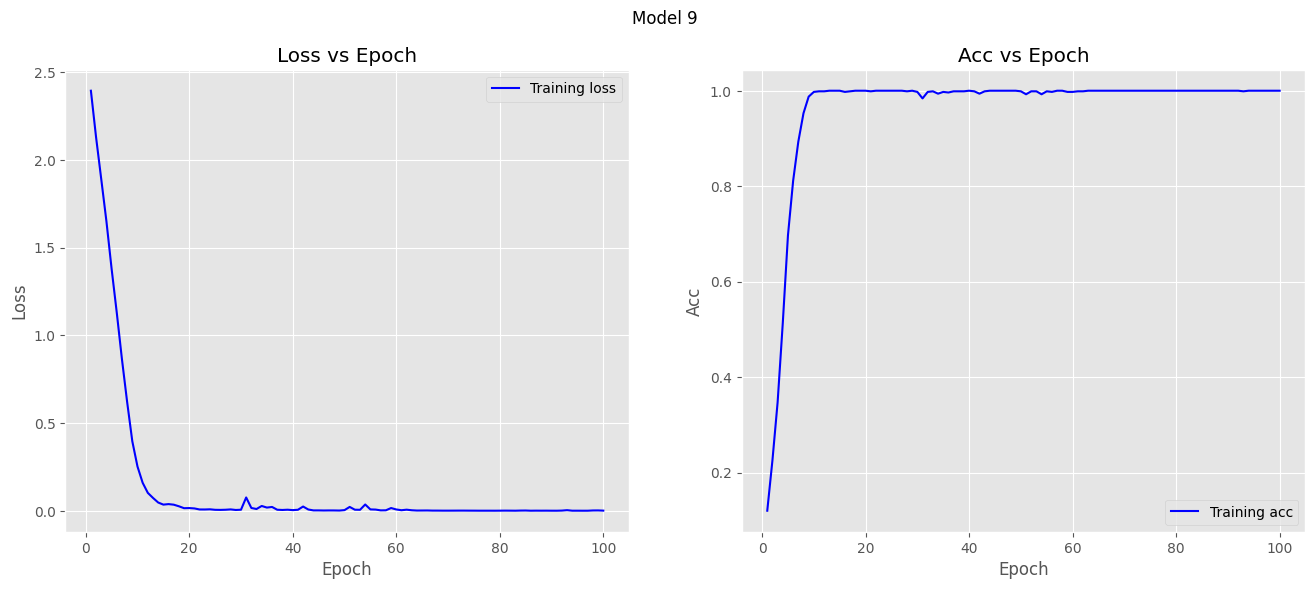

In [51]:
row, col = train_loss.shape

for i in range(row):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        # ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        # ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Model {i}")
        plt.show()

In [52]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32_epoch0.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.0965
Evaluating Run 1
Test Accuracy: 0.0965
Evaluating Run 2
Test Accuracy: 0.1002
Evaluating Run 3
Test Accuracy: 0.1243
Evaluating Run 4
Test Accuracy: 0.0891
Evaluating Run 5
Test Accuracy: 0.1243
Evaluating Run 6
Test Accuracy: 0.1150
Evaluating Run 7
Test Accuracy: 0.1429
Evaluating Run 8
Test Accuracy: 0.1466
Evaluating Run 9
Test Accuracy: 0.0872


In [53]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i in range(10):
    print(f"Evaluating Run {i}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run{i}_b32.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0
Test Accuracy: 0.4824
Evaluating Run 1
Test Accuracy: 0.4972
Evaluating Run 2
Test Accuracy: 0.4045
Evaluating Run 3
Test Accuracy: 0.4991
Evaluating Run 4
Test Accuracy: 0.4378
Evaluating Run 5
Test Accuracy: 0.5455
Evaluating Run 6
Test Accuracy: 0.5306
Evaluating Run 7
Test Accuracy: 0.4174
Evaluating Run 8
Test Accuracy: 0.5176
Evaluating Run 9
Test Accuracy: 0.4657


In [55]:
np.array(test_acc_lst).mean() * 100, np.array(test_acc_lst).std() * 100

(np.float64(47.977736549165115), np.float64(4.531005773655107))

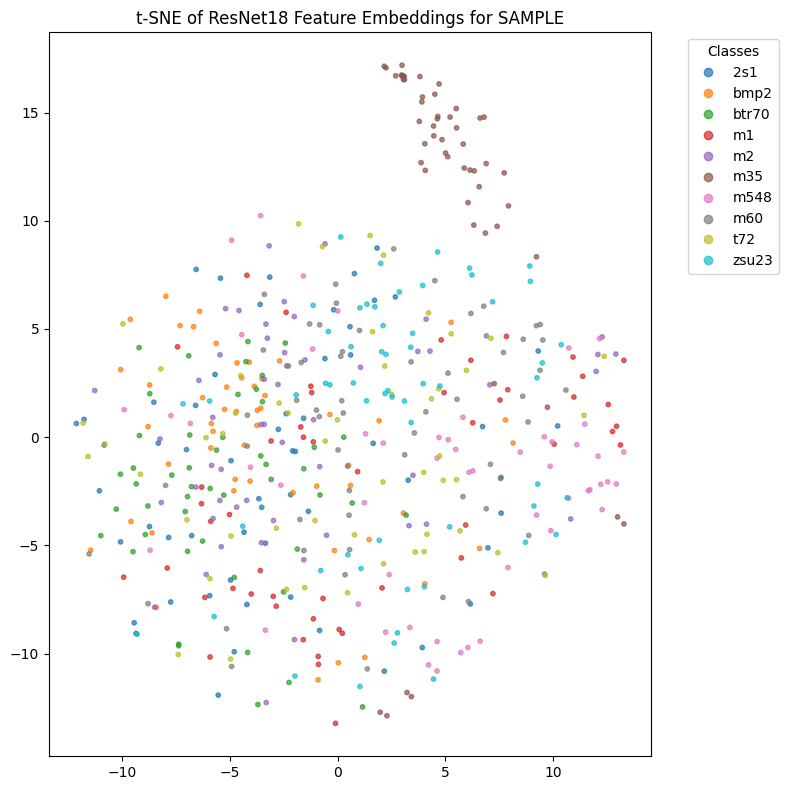

In [56]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

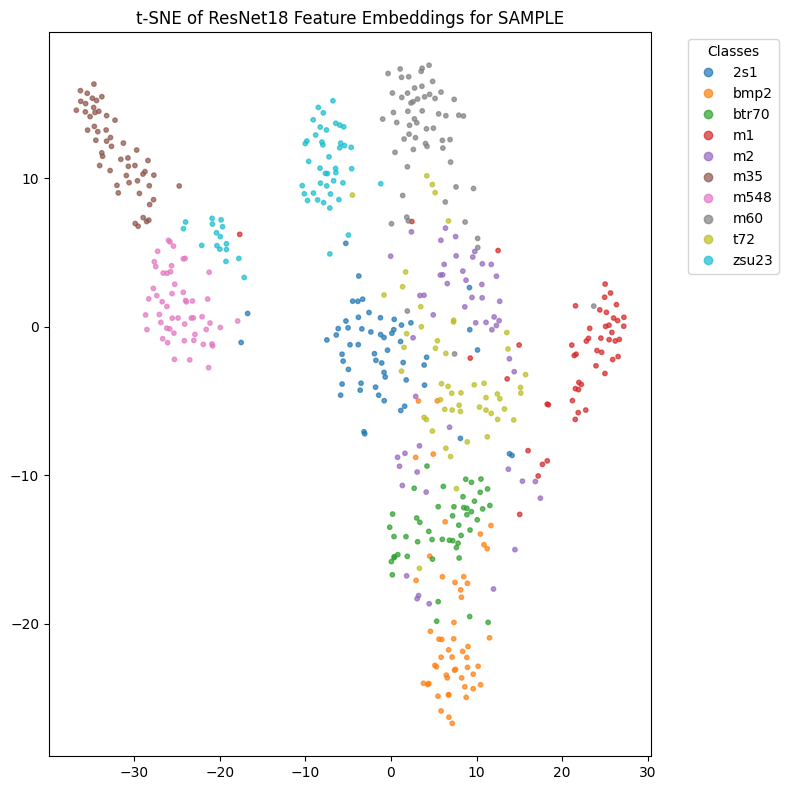

In [57]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

/home/alvinng44/.local/share/mamba/envs/alyssa/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


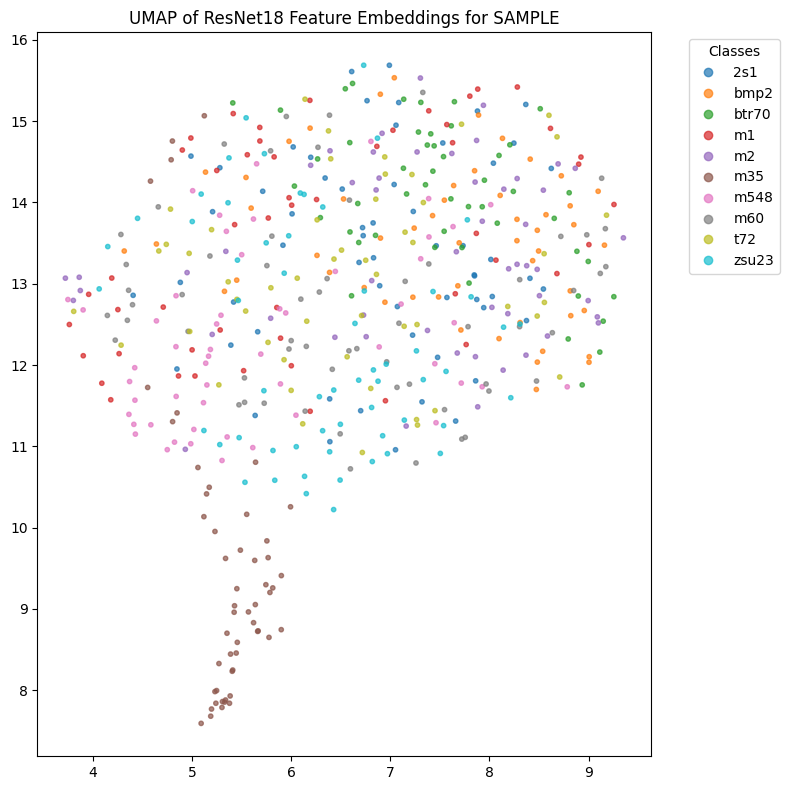

In [58]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32_epoch0.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

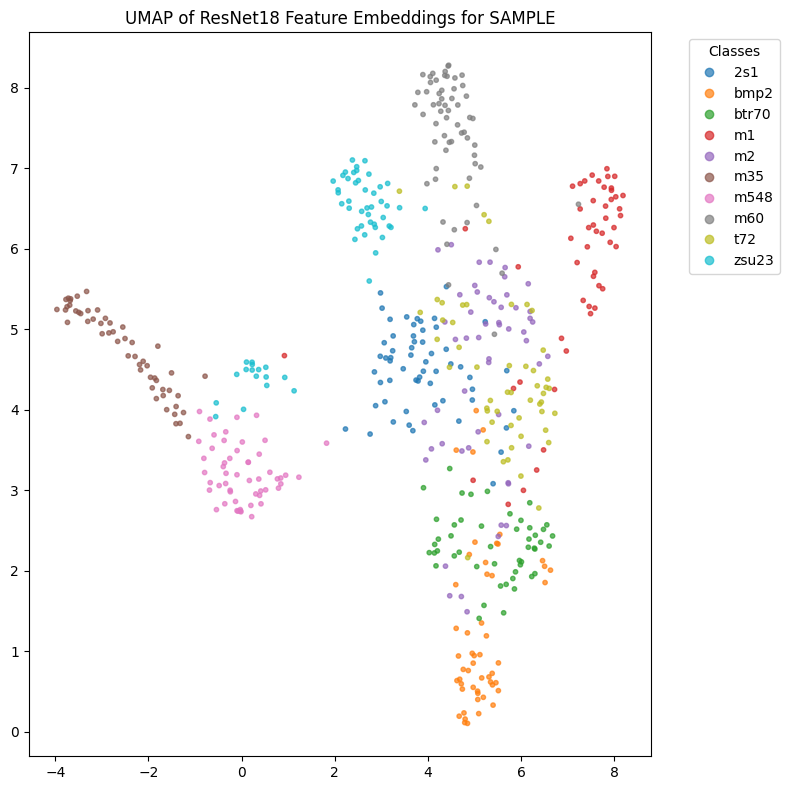

In [59]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/wo_aug/rn18_run8_b32.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in dataloaders["test"]:
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(train_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

In [23]:
train_ds.class_to_idx

{'2s1': 0,
 'bmp2': 1,
 'btr70': 2,
 'm1': 3,
 'm2': 4,
 'm35': 5,
 'm548': 6,
 'm60': 7,
 't72': 8,
 'zsu23': 9}